# 🌿 Leaf Disease Segmentation — YOLOv11
**Dataset:** [Leaf Disease Segmentation Dataset (Top Pick)](https://www.kaggle.com/datasets/fakhrealam9537/leaf-disease-segmentation-dataset)  
**Task:** Instance Segmentation with YOLOv11  
**Pipeline:** Dataset Loading → EDA → Training → Evaluation → Inference

---

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 0. 📦 Install Dependencies

In [5]:
# Install required packages
!pip install ultralytics kaggle opencv-python-headless matplotlib seaborn Pillow PyYAML tqdm --quiet

import subprocess, sys
print('Ultralytics version:', subprocess.check_output(['python', '-c', 'import ultralytics; print(ultralytics.__version__)']).decode().strip())

Ultralytics version: 8.4.50


## 1. 📥 Dataset Download (Kaggle API)

In [6]:
import os, json

# ── Option A: kaggle.json already placed at ~/.kaggle/kaggle.json ──────────────
# If running on Kaggle Notebooks, credentials are auto-injected — skip this cell.

# ── Option B: Paste credentials inline (Colab / local) ─────────────────────────
# Uncomment and fill in your Kaggle username & key:
# KAGGLE_USERNAME = "your_username"
# KAGGLE_KEY      = "your_api_key"
# os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
# with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
#     json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
# os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# ── Download ────────────────────────────────────────────────────────────────────
DATASET_SLUG = 'fakhrealam9537/leaf-disease-segmentation-dataset'
DATA_ROOT    = 'leaf_disease_dataset'

!kaggle datasets download -d {DATASET_SLUG} -p {DATA_ROOT} --unzip

print('Download complete.')
!find {DATA_ROOT} -maxdepth 3 -type d

Dataset URL: https://www.kaggle.com/datasets/fakhrealam9537/leaf-disease-segmentation-dataset
License(s): CC0-1.0
100%|█████████████████████████████████████████| 503M/503M [00:04<00:00, 127MB/s]

Download complete.
leaf_disease_dataset
leaf_disease_dataset/data
leaf_disease_dataset/data/data
leaf_disease_dataset/data/data/masks
leaf_disease_dataset/data/data/images
leaf_disease_dataset/aug_data
leaf_disease_dataset/aug_data/aug_data
leaf_disease_dataset/aug_data/aug_data/masks
leaf_disease_dataset/aug_data/aug_data/images


## 2. 🗂️ Explore Dataset Structure

In [20]:
import os
import cv2
import yaml
import shutil
import numpy as np
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Configuration
INPUT_ROOT = Path('/kaggle/input/datasets/fakhrealam9537/leaf-disease-segmentation-dataset')
OUTPUT_ROOT = Path('/kaggle/working/yolo_dataset')

# Helper to find folders regardless of nesting
def find_dir(root, name):
    for p in root.rglob('*'):
        if p.is_dir() and p.name == name:
            return p
    return None

IMG_SRC = find_dir(INPUT_ROOT, 'images')
MASK_SRC = find_dir(INPUT_ROOT, 'masks')

print(f"Source Images: {IMG_SRC}")
print(f"Source Masks:  {MASK_SRC}")

Source Images: /kaggle/input/datasets/fakhrealam9537/leaf-disease-segmentation-dataset/aug_data/aug_data/images
Source Masks:  /kaggle/input/datasets/fakhrealam9537/leaf-disease-segmentation-dataset/aug_data/aug_data/masks


### Mask-to-YOLO Conversion Logic

In [27]:
def mask_to_yolo(mask_path, img_size):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None: return ""
    
    # Threshold to binary (treat any non-black pixel as the disease)
    _, binary = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    yolo_polygons = []
    h, w = img_size
    for cnt in contours:
        if len(cnt) < 3: continue # Skip noise
        poly = cnt.reshape(-1, 2).astype(np.float32)
        poly[:, 0] /= w # Normalize X
        poly[:, 1] /= h # Normalize Y
        line = "0 " + " ".join([f"{x:.6f} {y:.6f}" for x, y in poly])
        yolo_polygons.append(line)
    return "\n".join(yolo_polygons)

### Process and Split Data

In [28]:
# Get all image files
all_images = sorted(list(IMG_SRC.glob('*.jpg')) + list(IMG_SRC.glob('*.png')))
train_imgs, val_imgs = train_test_split(all_images, test_size=0.15, random_state=42)

for split, files in [('train', train_imgs), ('val', val_imgs)]:\
    # Create directories
    (OUTPUT_ROOT / split / 'images').mkdir(parents=True, exist_ok=True)
    (OUTPUT_ROOT / split / 'labels').mkdir(parents=True, exist_ok=True)
    
    for img_p in tqdm(files, desc=f"Processing {split}"):
        # Match mask filename to image filename
        mask_p = MASK_SRC / (img_p.stem + ".png") 
        if not mask_p.exists(): mask_p = MASK_SRC / img_p.name
        
        if mask_p.exists():
            img = cv2.imread(str(img_p))
            yolo_labels = mask_to_yolo(mask_p, img.shape[:2])
            
            if yolo_labels:
                # Copy Image to working directory
                shutil.copy(img_p, OUTPUT_ROOT / split / 'images' / img_p.name)
                # Write the new .txt Label
                label_path = OUTPUT_ROOT / split / 'labels' / (img_p.stem + ".txt")
                with open(label_path, 'w') as f:
                    f.write(yolo_labels)

print(f"✅ Setup Complete. Files are in {OUTPUT_ROOT}")

Processing val: 100%|██████████| 441/441 [00:10<00:00, 43.32it/s]

✅ Setup Complete. Files are in /kaggle/working/yolo_dataset


### Create YAML Config

In [30]:
dataset_yaml = {
    'path': str(OUTPUT_ROOT),
    'train': 'train/images',
    'val': 'val/images',
    'nc': 1,
    'names': ['leaf_disease']
}

with open('/kaggle/working/leaf_disease.yaml', 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print("YAML created.")

YAML created.


In [32]:
import yaml

# Since we created the YAML in the previous step, we point directly to it
YAML_PATH = '/kaggle/working/leaf_disease.yaml'

if os.path.exists(YAML_PATH):
    with open(YAML_PATH) as f:
        data_cfg = yaml.safe_load(f)
    print('✅ Dataset YAML loaded successfully:')
    print(yaml.dump(data_cfg, default_flow_style=False))
    
    CLASS_NAMES = data_cfg.get('names', [])
    NC = data_cfg.get('nc', len(CLASS_NAMES))
else:
    # Fallback in case the file wasn't created in the previous step
    print('[ERROR] YAML file not found at /kaggle/working/leaf_disease.yaml')
    print('Ensuring default values are set...')
    NC = 1
    CLASS_NAMES = ['leaf_disease']

print(f'Final Configuration: {NC} classes -> {CLASS_NAMES}')

✅ Dataset YAML loaded successfully:
names:
- leaf_disease
nc: 1
path: /kaggle/working/yolo_dataset
train: train/images
val: val/images

Final Configuration: 1 classes -> ['leaf_disease']


In [35]:
# Update file lists to point to the newly created working directory
all_images = sorted(list((OUTPUT_ROOT / 'train' / 'images').glob('*')) + 
                   list((OUTPUT_ROOT / 'val' / 'images').glob('*')))
all_labels = sorted(list((OUTPUT_ROOT / 'train' / 'labels').glob('*')) + 
                   list((OUTPUT_ROOT / 'val' / 'labels').glob('*')))

## 3. 📊 Exploratory Data Analysis (EDA)

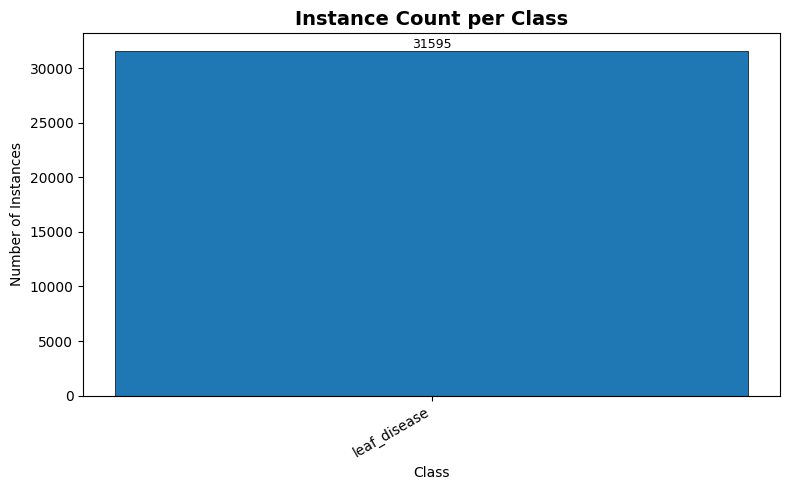

Class distribution saved.


In [36]:
import matplotlib.pyplot as plt
from collections import Counter

class_counter = Counter()
for lf in all_labels:
    with open(lf) as f:
        for line in f.read().strip().splitlines():
            if line:
                class_counter[int(line.split()[0])] += 1

labels_sorted = sorted(class_counter.items())
ids   = [x[0] for x in labels_sorted]
counts = [x[1] for x in labels_sorted]
names  = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f'cls_{i}' for i in ids]

fig, ax = plt.subplots(figsize=(max(8, len(ids)*0.9), 5))
bars = ax.bar(names, counts, color=plt.cm.tab20.colors[:len(ids)], edgecolor='black', linewidth=0.5)
ax.set_title('Instance Count per Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Instances')
ax.bar_label(bars, fmt='%d', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()
print('Class distribution saved.')

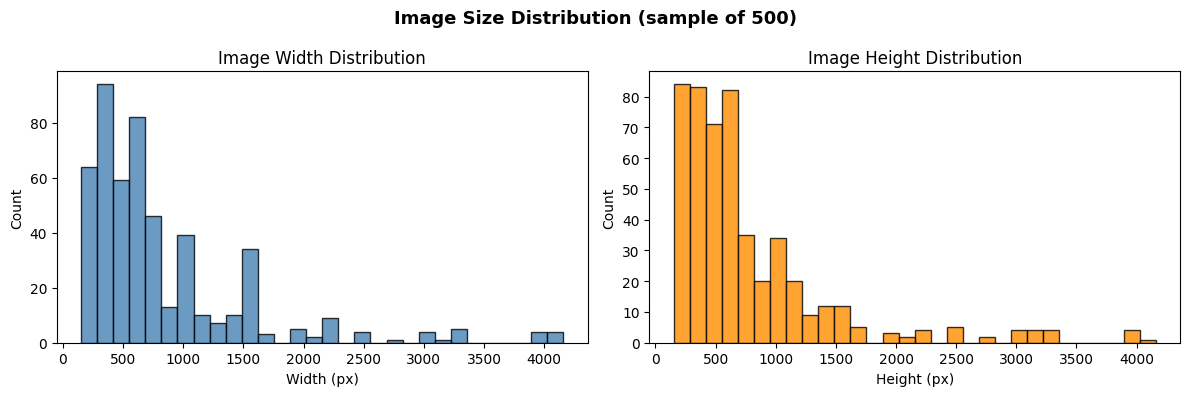

W: min=150, max=4160, mean=833
H: min=150, max=4160, mean=773


In [37]:
from PIL import Image

sample_imgs = all_images[:500]
widths, heights = [], []
for p in sample_imgs:
    try:
        with Image.open(p) as img:
            widths.append(img.width)
            heights.append(img.height)
    except Exception:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color='steelblue',  edgecolor='black', alpha=0.8)
axes[0].set_title('Image Width Distribution');  axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=30, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_title('Image Height Distribution'); axes[1].set_xlabel('Height (px)')
for ax in axes:
    ax.set_ylabel('Count')
plt.suptitle('Image Size Distribution (sample of 500)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_image_sizes.png', dpi=150)
plt.show()
print(f'W: min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}')
print(f'H: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}')

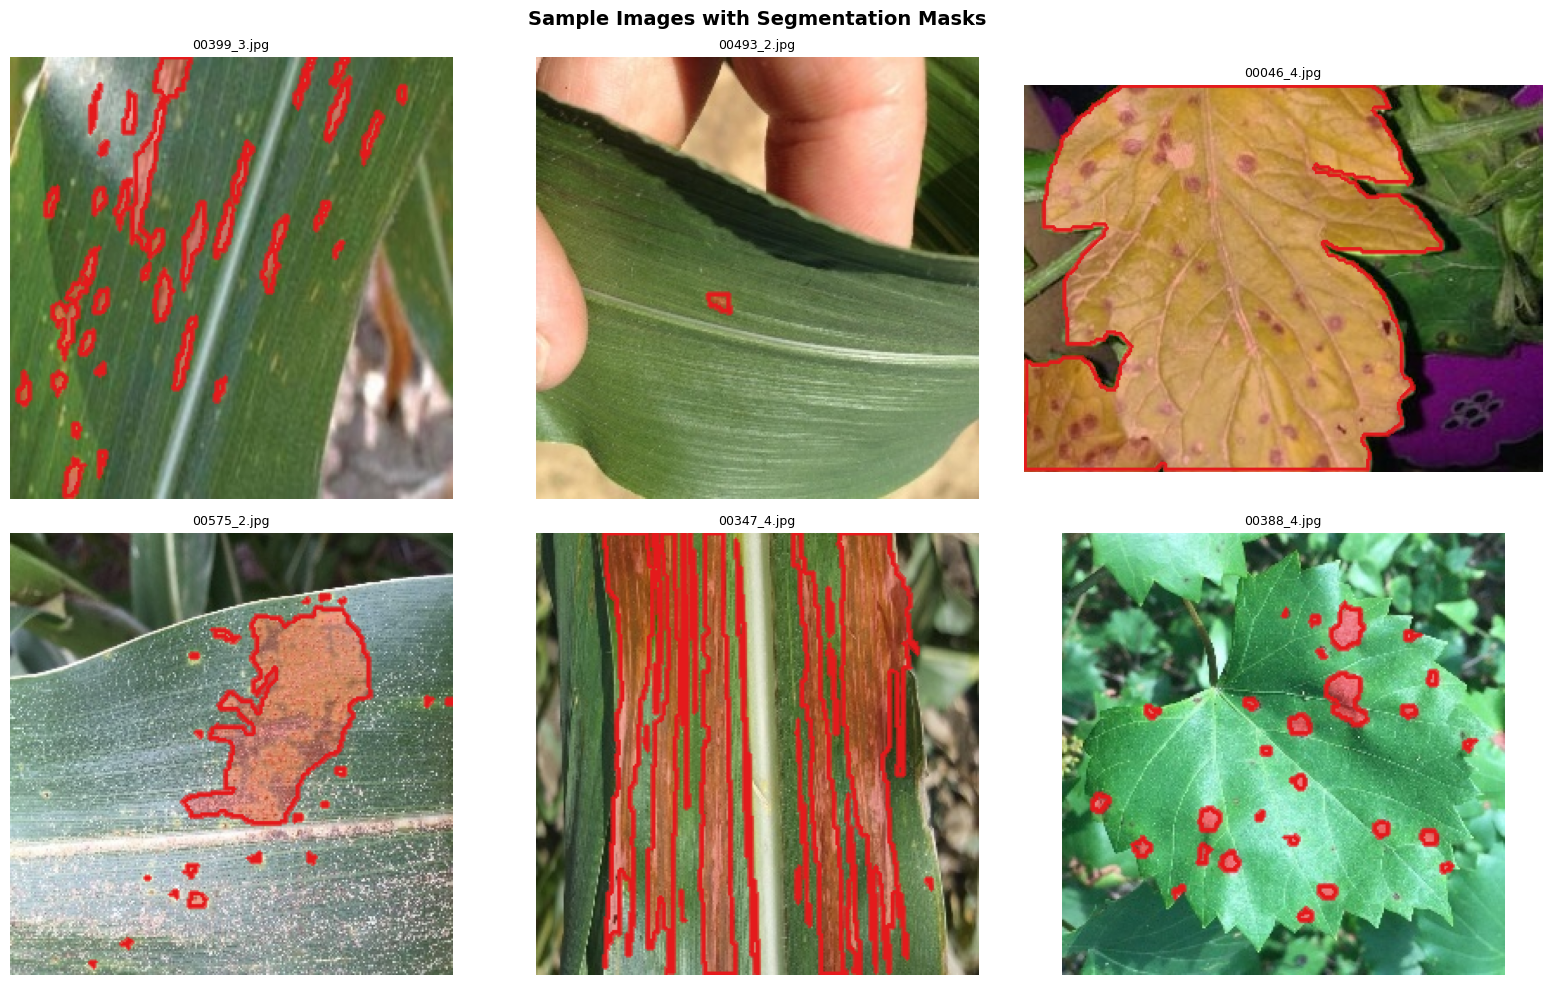

In [38]:
import random

COLORS = plt.cm.Set1.colors

def draw_seg_masks(img_path, label_path, class_names, colors):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()

    if not Path(label_path).exists():
        return img

    with open(label_path) as f:
        for line in f.read().strip().splitlines():
            parts = list(map(float, line.split()))
            cls   = int(parts[0])
            pts   = np.array(parts[1:]).reshape(-1, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
            pts = pts.astype(np.int32)
            color = tuple(int(c*255) for c in colors[cls % len(colors)][:3])
            cv2.fillPoly(overlay, [pts], color)
            cv2.polylines(img, [pts], True, color, 2)
            
    result = cv2.addWeighted(overlay, 0.35, img, 0.65, 0)
    return result

# Link images to their new labels in /working/
paired = []
for ip in all_images:
    lp = Path(str(ip).replace('images', 'labels')).with_suffix('.txt')
    if lp.exists() and lp.stat().st_size > 0:
        paired.append((ip, lp))

sample_pairs = random.sample(paired, min(6, len(paired)))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (ip, lp) in zip(axes.flatten(), sample_pairs):
    vis = draw_seg_masks(ip, lp, CLASS_NAMES, COLORS)
    ax.imshow(vis)
    ax.set_title(ip.name, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images with Segmentation Masks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

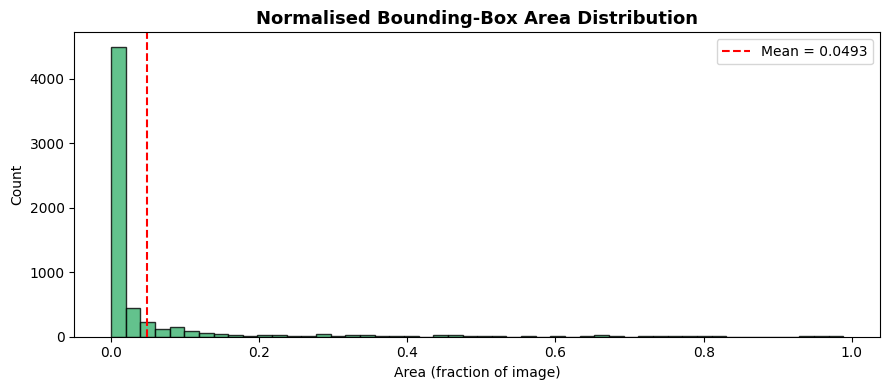

In [41]:
bbox_areas = []
for _, lp in paired[:1000]:
    with open(lp) as f:
        for line in f.read().strip().splitlines():
            parts = list(map(float, line.split()))
            pts   = np.array(parts[1:]).reshape(-1, 2)
            w_box = pts[:, 0].max() - pts[:, 0].min()
            h_box = pts[:, 1].max() - pts[:, 1].min()
            bbox_areas.append(w_box * h_box)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(bbox_areas, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.8)
ax.set_title('Normalised Bounding-Box Area Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Area (fraction of image)')
ax.set_ylabel('Count')
ax.axvline(np.mean(bbox_areas), color='red', linestyle='--', label=f'Mean = {np.mean(bbox_areas):.4f}')
ax.legend()
plt.tight_layout()
plt.show()

## 4. ⚙️ Prepare YAML Config for YOLOv11

In [42]:
import yaml
from pathlib import Path

# We already verified the YAML content is correct. 
# This cell simply double-checks the paths exist before training.
YAML_OUT = '/kaggle/working/leaf_disease.yaml'

with open(YAML_OUT, 'r') as f:
    config = yaml.safe_load(f)

print(f"--- Dataset Config Verification ---")
print(f"Train Path: {config['path']}/{config['train']}")
print(f"Val Path:   {config['path']}/{config['val']}")

if os.path.exists(Path(config['path']) / config['train']):
    print("✅ Training images found!")
else:
    print("❌ Training images NOT found. Check folder names.")

print("\nFinal YAML Contents:")
print(yaml.dump(config, default_flow_style=False))

--- Dataset Config Verification ---
Train Path: /kaggle/working/yolo_dataset/train/images
Val Path:   /kaggle/working/yolo_dataset/val/images
✅ Training images found!

Final YAML Contents:
names:
- leaf_disease
nc: 1
path: /kaggle/working/yolo_dataset
train: train/images
val: val/images



## 5. 🏋️ Model Training — YOLOv11 Segmentation

In [47]:
from ultralytics import YOLO

# ── Hyperparameters ─────────────────────────────────────────────────────────────
MODEL_SIZE  = 's'      # Using nano for speed
IMG_SIZE    = 640      
EPOCHS      = 100       
BATCH_SIZE  = 32       
LR0         = 0.01
PATIENCE    = 20       
PROJECT_DIR = 'runs/leaf_disease_seg'
RUN_NAME    = f'yolo11{MODEL_SIZE}-seg'

# ── Load pretrained YOLOv11-seg model ───────────────────────────────────────────
model = YOLO(f'yolo11{MODEL_SIZE}-seg.pt')

# NC=1 for leaf disease dataset
print(f'Model: yolo11{MODEL_SIZE}-seg  |  Classes: 1  |  Img: {IMG_SIZE}  |  Epochs: {EPOCHS}')

Model: yolo11s-seg  |  Classes: 1  |  Img: 640  |  Epochs: 100


In [49]:
# ── Train ────────────────────────────────────────────────────────────────────────
results = model.train(
    data        = '/kaggle/working/leaf_disease.yaml',
    epochs      = EPOCHS,
    imgsz       = IMG_SIZE,
    batch       = BATCH_SIZE,
    lr0         = LR0,
    patience    = PATIENCE,
    project     = PROJECT_DIR,
    name        = RUN_NAME,
    save        = True,
    plots       = True,
    augment     = True,
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    degrees     = 10.0,
    translate   = 0.1,
    scale       = 0.5,
    flipud      = 0.2,
    fliplr      = 0.5,
    mosaic      = 1.0,
    copy_paste  = 0.1,
    device      = 0,      # First T4 GPU
    workers     = 4,
    verbose     = True,
)

BEST_WEIGHTS = results.save_dir / 'weights' / 'best.pt'
print(f'\nTraining complete. Best weights: {BEST_WEIGHTS}')

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/leaf_disease.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s-seg-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

In [50]:
from ultralytics import YOLO

# 1. Load the best weights from the previous 100-epoch run
# Based on your output, the path was: /kaggle/working/runs/segment/runs/leaf_disease_seg/yolo11s-seg-2/weights/best.pt
FINE_TUNE_WEIGHTS = '/kaggle/working/runs/segment/runs/leaf_disease_seg/yolo11s-seg-2/weights/best.pt'
model = YOLO(FINE_TUNE_WEIGHTS)

# 2. Fine-tuning Hyperparameters
# We use a much lower learning rate (lr0) so we don't destroy the learned weights
FT_EPOCHS = 30          # A shorter cycle is usually enough for fine-tuning
FT_LR0 = 0.001          # Reduced from 0.01 to 0.001 for stability
FT_RUN_NAME = f'{RUN_NAME}-fine-tune'

# 3. Start Fine-tuning
ft_results = model.train(
    data        = '/kaggle/working/leaf_disease.yaml',
    epochs      = FT_EPOCHS,
    imgsz       = IMG_SIZE,
    batch       = BATCH_SIZE,
    lr0         = FT_LR0,        # Lower learning rate for fine-tuning
    patience    = 10,            # Tighter patience for the final squeeze
    project     = PROJECT_DIR,
    name        = FT_RUN_NAME,
    save        = True,
    plots       = True,
    augment     = True,          # Keep augmentations on to prevent overfitting
    # ── Keep the existing augmentation settings ──────────────────────────────
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    degrees     = 10.0,
    translate   = 0.1,
    scale       = 0.5,
    flipud      = 0.2,
    fliplr      = 0.5,
    mosaic      = 1.0,
    copy_paste  = 0.1,
    # ──────────────────────────────────────────────────────────────────────────
    device      = 0,
    workers     = 4,
    verbose     = True,
)

# Update BEST_WEIGHTS to the new fine-tuned version
BEST_WEIGHTS = ft_results.save_dir / 'weights' / 'best.pt'
print(f'\nFine-tuning complete. New best weights: {BEST_WEIGHTS}')

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/leaf_disease.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/runs/segment/runs/leaf_disease_seg/yolo11s-seg-2/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s-seg-fine-tune, nbs=64,

In [54]:
import shutil
import os

# Create a zip of the results so they are easy to download tomorrow
os.chdir('/kaggle/working')
if os.path.exists('runs'):
    shutil.make_archive('yolo_final_results', 'zip', 'runs')
    print("SUCCESS: Results zipped and ready for permanent storage.")

SUCCESS: Results zipped and ready for permanent storage.


## 6. 📈 Training Curves

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_csv = Path(results.save_dir) / 'results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

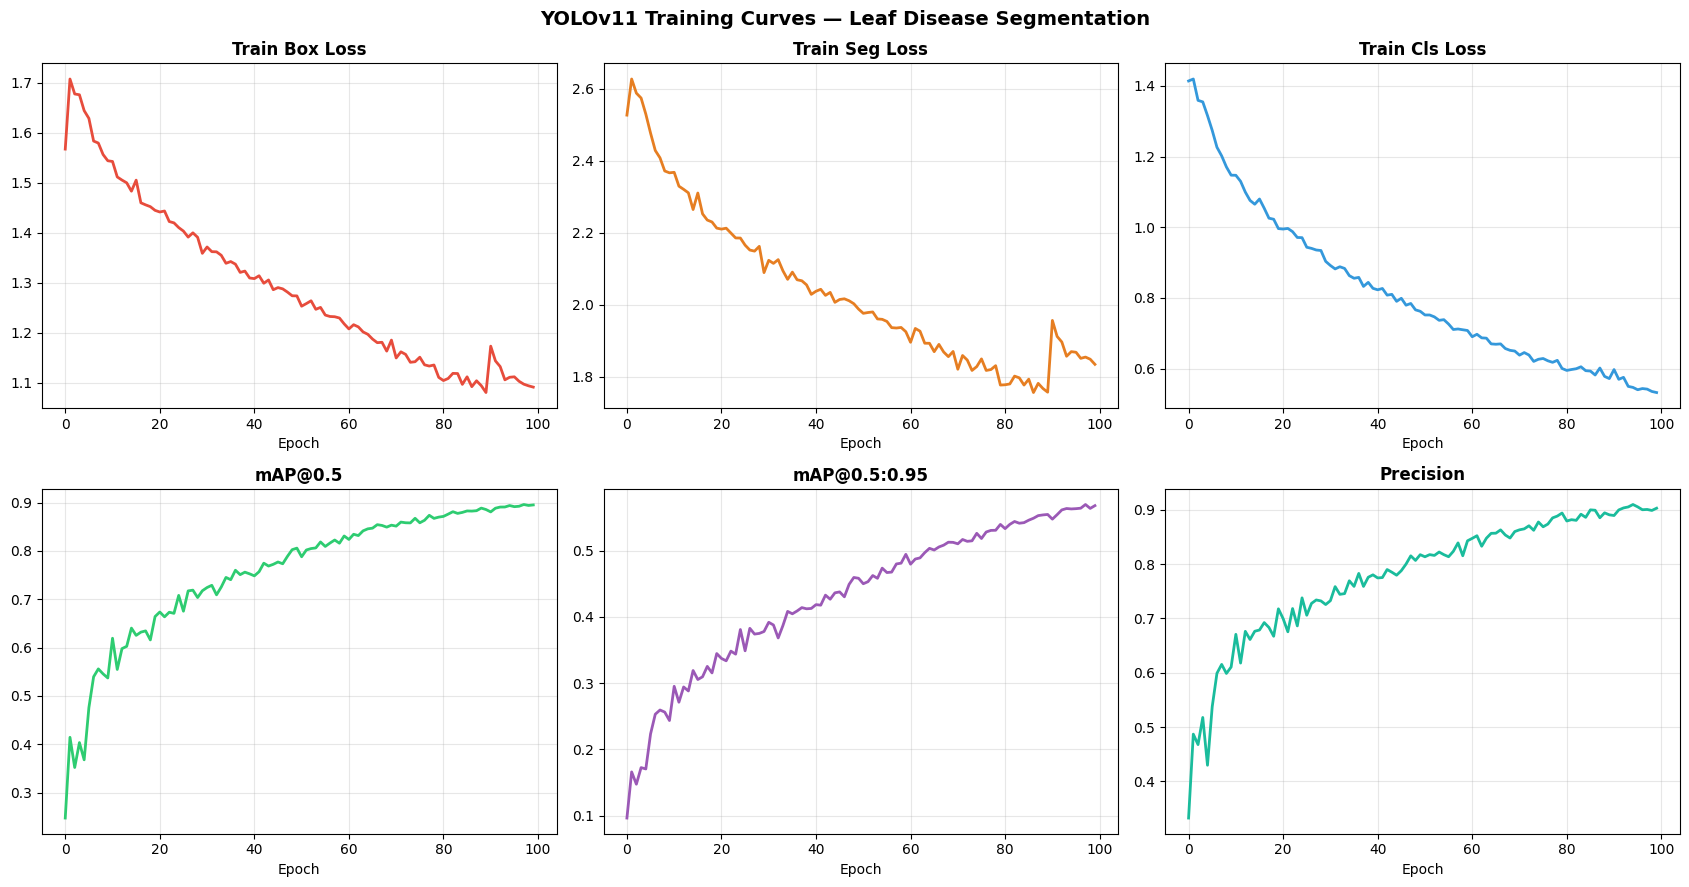

In [56]:
# ── Plot key metrics ─────────────────────────────────────────────────────────────
# Map possible column names across YOLO versions
col_map = {
    'box_loss'  : [c for c in df.columns if 'box' in c.lower() and 'loss' in c.lower() and 'train' in c.lower()],
    'seg_loss'  : [c for c in df.columns if 'seg' in c.lower() and 'loss' in c.lower() and 'train' in c.lower()],
    'cls_loss'  : [c for c in df.columns if 'cls' in c.lower() and 'loss' in c.lower() and 'train' in c.lower()],
    'mAP50'     : [c for c in df.columns if 'map50' in c.lower() and '(b)' in c.lower()],
    'mAP50-95'  : [c for c in df.columns if 'map50-95' in c.lower() and '(b)' in c.lower()],
    'precision' : [c for c in df.columns if 'precision' in c.lower() and '(b)' in c.lower()],
}
resolved = {k: v[0] for k, v in col_map.items() if v}

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()
palette = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71', '#9b59b6', '#1abc9c']
plot_order = ['box_loss', 'seg_loss', 'cls_loss', 'mAP50', 'mAP50-95', 'precision']
titles     = ['Train Box Loss', 'Train Seg Loss', 'Train Cls Loss', 'mAP@0.5', 'mAP@0.5:0.95', 'Precision']

for ax, key, title, color in zip(axes, plot_order, titles, palette):
    if key in resolved:
        ax.plot(df[resolved[key]], color=color, linewidth=2)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

plt.suptitle('YOLOv11 Training Curves — Leaf Disease Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. 🧪 Evaluation on Validation Set

In [57]:
# Load best checkpoint
best_model = YOLO(str(BEST_WEIGHTS))

val_metrics = best_model.val(
    data    = '/kaggle/working/leaf_disease.yaml',
    imgsz   = IMG_SIZE,
    split   = 'val',
    device  = 0,
    plots   = True,
    save_json = True,
)

print('\n=== Validation Metrics ===')
print(f'Precision  (B): {val_metrics.box.mp:.4f}')
print(f'Recall     (B): {val_metrics.box.mr:.4f}')
print(f'mAP@0.5    (B): {val_metrics.box.map50:.4f}')
print(f'mAP@0.5:95 (B): {val_metrics.box.map:.4f}')
if hasattr(val_metrics, 'seg'):
    print(f'mAP@0.5    (M): {val_metrics.seg.map50:.4f}')
    print(f'mAP@0.5:95 (M): {val_metrics.seg.map:.4f}')

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1944.2±1385.8 MB/s, size: 146.7 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 441 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 441/441 154.1Mit/s 0.0s
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 302ms
Prepared 1 package in 53ms
Installed 1 package in 8ms
 + faster-coco-eval==1.7.2

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 1.3it/s 21.6s0.5ss
                   all        441       4

In [58]:
# ── Per-class metrics table ──────────────────────────────────────────────────────
import pandas as pd

try:
    per_class = pd.DataFrame({
        'Class'    : CLASS_NAMES[:len(val_metrics.box.ap_class_index)],
        'AP@0.5'   : val_metrics.box.ap50,
        'AP@0.5:95': val_metrics.box.ap,
    })
    print(per_class.to_string(index=False))
except Exception as e:
    print(f'Per-class table unavailable: {e}')

       Class   AP@0.5  AP@0.5:95
leaf_disease 0.876142   0.538888


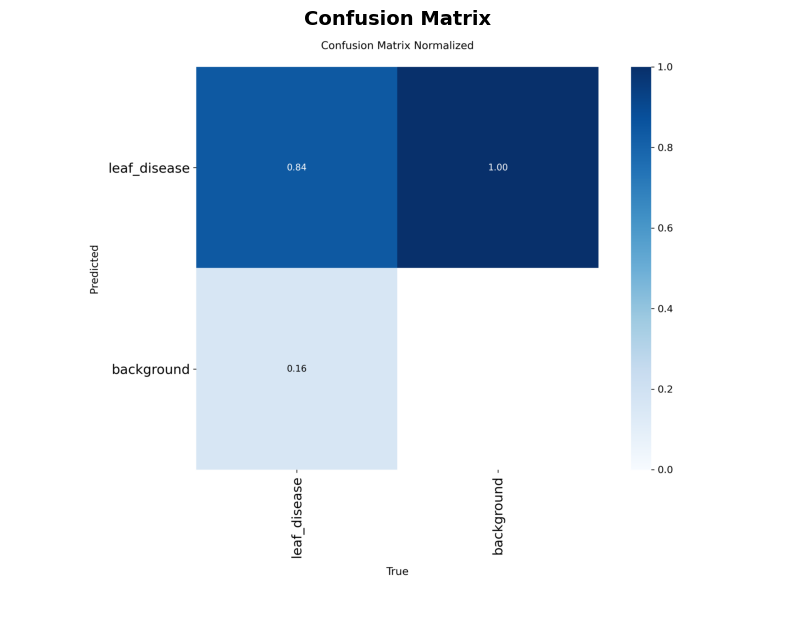

In [59]:
# ── Confusion matrix ─────────────────────────────────────────────────────────────
cm_path = Path(val_metrics.save_dir) / 'confusion_matrix_normalized.png'
if not cm_path.exists():
    cm_path = Path(val_metrics.save_dir) / 'confusion_matrix.png'

if cm_path.exists():
    img = plt.imread(str(cm_path))
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()

## 8. 🔍 Inference & Visualisation

In [60]:
import cv2, random
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from ultralytics import YOLO

best_model = YOLO(str(BEST_WEIGHTS))

# ── Pick test images (prefer test split; fall back to val) ───────────────────────
def find_split_images(root, splits):
    for s in splits:
        imgs = list((root / s / 'images').glob('*.*'))
        if imgs:
            return imgs
    return all_images

test_images = find_split_images(DATA_ROOT, ['test', 'val', 'valid'])
sample_test = random.sample(test_images, min(8, len(test_images)))

print(f'Running inference on {len(sample_test)} images...')

preds = best_model.predict(
    source   = [str(p) for p in sample_test],
    imgsz    = IMG_SIZE,
    conf     = 0.25,
    iou      = 0.45,
    device   = 0,
    save     = False,
    retina_masks = True,
)

Running inference on 8 images...

0: 640x640 26 leaf_diseases, 15.4ms
1: 640x640 13 leaf_diseases, 15.4ms
2: 640x640 10 leaf_diseases, 15.4ms
3: 640x640 1 leaf_disease, 15.4ms
4: 640x640 5 leaf_diseases, 15.4ms
5: 640x640 2 leaf_diseases, 15.4ms
6: 640x640 16 leaf_diseases, 15.4ms
7: 640x640 9 leaf_diseases, 15.4ms
Speed: 3.3ms preprocess, 15.4ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)


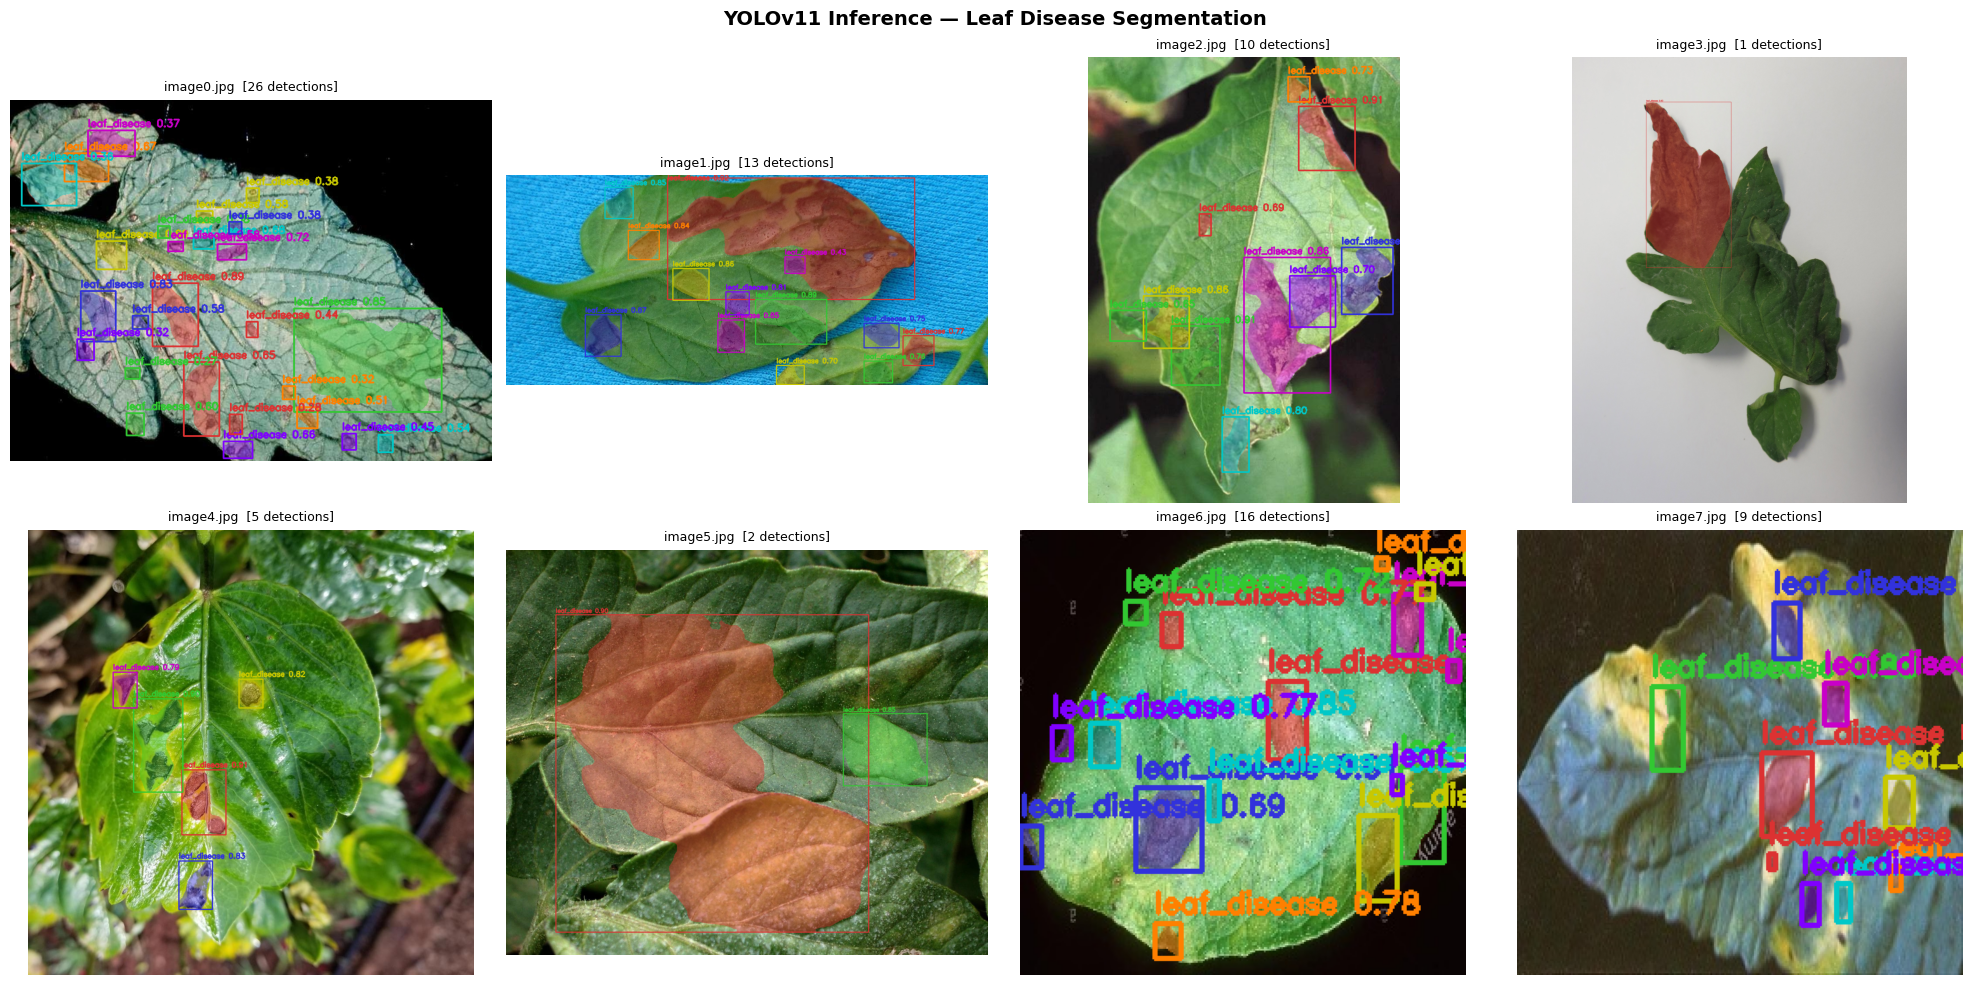

Inference visualisation saved.


In [61]:
# ── Helper: draw prediction masks & boxes ────────────────────────────────────────
def visualise_prediction(result, class_names, alpha=0.45):
    img = result.orig_img.copy()          # BGR numpy
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy()
    h, w = img.shape[:2]

    palette = [
        (220, 50, 50), (50, 200, 50), (50, 50, 220), (200, 200, 0),
        (200, 0, 200), (0, 200, 200), (255, 128, 0), (128, 0, 255)
    ]

    if result.masks is not None:
        for i, mask in enumerate(result.masks.data):
            mask_np = mask.cpu().numpy()
            if mask_np.shape != (h, w):
                mask_np = cv2.resize(mask_np, (w, h), interpolation=cv2.INTER_NEAREST)
            color = palette[i % len(palette)]
            for c in range(3):
                overlay[:, :, c] = np.where(mask_np > 0.5, color[c], overlay[:, :, c])

    blended = cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0)

    if result.boxes is not None:
        for i, (box, conf, cls) in enumerate(zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.conf.cpu().numpy(),
            result.boxes.cls.cpu().numpy()
        )):
            x1, y1, x2, y2 = map(int, box)
            color = palette[i % len(palette)]
            cv2.rectangle(blended, (x1, y1), (x2, y2), color, 2)
            label = f"{class_names[int(cls)] if int(cls) < len(class_names) else int(cls)} {conf:.2f}"
            cv2.putText(blended, label, (x1, max(y1-6, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    return blended


# ── Plot 8 predictions ───────────────────────────────────────────────────────────
ncols, nrows = 4, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10))

for ax, result in zip(axes.flatten(), preds):
    vis = visualise_prediction(result, CLASS_NAMES)
    ax.imshow(vis)
    n_det = len(result.boxes) if result.boxes else 0
    ax.set_title(f'{Path(result.path).name}  [{n_det} detections]', fontsize=9)
    ax.axis('off')

# Turn off unused axes
for ax in axes.flatten()[len(preds):]:
    ax.axis('off')

plt.suptitle('YOLOv11 Inference — Leaf Disease Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_results.png', dpi=150)
plt.show()
print('Inference visualisation saved.')

## 9. 📦 Export Model (Optional)

In [62]:
# ── Export to ONNX (for deployment) ─────────────────────────────────────────────
# Other formats: 'torchscript' | 'engine' (TensorRT) | 'tflite' | 'coreml'
export_path = best_model.export(
    format  = 'onnx',
    imgsz   = IMG_SIZE,
    opset   = 17,
    simplify= True,
    dynamic = False,
)
print(f'Model exported to: {export_path}')

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/segment/runs/leaf_disease_seg/yolo11s-seg-fine-tune/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (19.5 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 163ms
Prepared 2 packages in 2.71s
Installed 2 packages in 8ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 6.2s, saved as '/kagg

## 10. 🧮 Inference on a Single New Image


image 1/1 /kaggle/working/yolo_dataset/train/images/00135_3.jpg: 480x640 17 leaf_diseases, 74.0ms
Speed: 2.9ms preprocess, 74.0ms inference, 3.8ms postprocess per image at shape (1, 3, 480, 640)
Image       : /kaggle/working/yolo_dataset/train/images/00135_3.jpg
Detections  : 17
  [0] leaf_disease — conf: 0.871
  [1] leaf_disease — conf: 0.871
  [2] leaf_disease — conf: 0.844
  [3] leaf_disease — conf: 0.801
  [4] leaf_disease — conf: 0.671
  [5] leaf_disease — conf: 0.633
  [6] leaf_disease — conf: 0.616
  [7] leaf_disease — conf: 0.594
  [8] leaf_disease — conf: 0.519
  [9] leaf_disease — conf: 0.518
  [10] leaf_disease — conf: 0.518
  [11] leaf_disease — conf: 0.492
  [12] leaf_disease — conf: 0.465
  [13] leaf_disease — conf: 0.464
  [14] leaf_disease — conf: 0.362
  [15] leaf_disease — conf: 0.323
  [16] leaf_disease — conf: 0.315


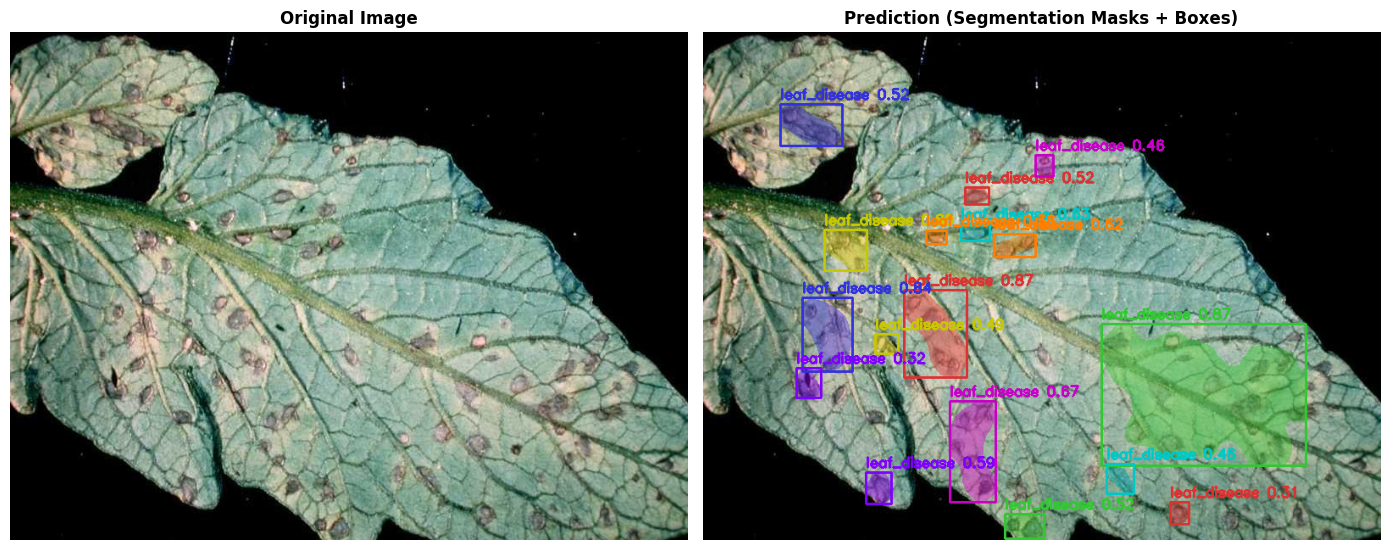

In [63]:
# ── Single-image inference pipeline ─────────────────────────────────────────────
INFERENCE_IMG = str(sample_test[0])   # Replace with any image path

result = best_model.predict(
    source       = INFERENCE_IMG,
    imgsz        = IMG_SIZE,
    conf         = 0.25,
    iou          = 0.45,
    device       = 0,
    retina_masks = True,
)[0]

# ── Summary ──────────────────────────────────────────────────────────────────────
print(f'Image       : {INFERENCE_IMG}')
print(f'Detections  : {len(result.boxes) if result.boxes else 0}')
if result.boxes and len(result.boxes) > 0:
    for i, (cls, conf) in enumerate(zip(
        result.boxes.cls.cpu().numpy(),
        result.boxes.conf.cpu().numpy()
    )):
        cname = CLASS_NAMES[int(cls)] if int(cls) < len(CLASS_NAMES) else int(cls)
        print(f'  [{i}] {cname} — conf: {conf:.3f}')

# ── Visualise ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
orig = cv2.cvtColor(result.orig_img, cv2.COLOR_BGR2RGB)
axes[0].imshow(orig)
axes[0].set_title('Original Image', fontweight='bold')
axes[0].axis('off')

vis = visualise_prediction(result, CLASS_NAMES)
axes[1].imshow(vis)
axes[1].set_title('Prediction (Segmentation Masks + Boxes)', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('single_inference.png', dpi=150)
plt.show()

## 11. 📋 Summary

| Section | Description |
|---------|-------------|
| **Dataset** | Leaf Disease Segmentation Dataset (Kaggle, polygon masks in YOLO seg format) |
| **Model** | YOLOv11-seg (pretrained on COCO, fine-tuned on leaf disease) |
| **Input size** | 640×640 |
| **Augmentations** | HSV jitter, flips, mosaic, copy-paste, affine |
| **EDA outputs** | Class distribution, image size histograms, mask overlays, bbox area distribution |
| **Evaluation** | mAP@0.5, mAP@0.5:95 (box + mask), per-class AP, confusion matrix |
| **Export** | ONNX (change `format` to `engine` for TensorRT) |

